## 1.0 Data Collection & Preparation

### 1.1 Important Libraries

In [ ]:
# Data Handling & Analysis
import numpy as np
import pandas as pd
from datasets import Dataset

# NLP
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Deep Learning
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Evaluation
import evaluate

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

Option A: Download ready-made datasets from Kaggle, UCI ML Repository, or HuggingFace

In [ ]:
df = pd.read_csv("C:/Users/user/Downloads/archive (3)/googleplaystore_user_reviews.csv")
print("DataFrame Information")
print(df.info())

print("\nDataFrame Description")
print(df.describe())

print("\nCheck missing values in DataFrame")
print(df.isna().sum())

# Remove empty rows
df = df.dropna(how='any')

# Create new dataframe containing only 2 columns ('Translated Review' and 'Sentiment')
df = df[['Translated_Review', 'Sentiment']]

df

DataFrame Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB
None

DataFrame Description
       Sentiment_Polarity  Sentiment_Subjectivity
count        37432.000000            37432.000000
mean             0.182146                0.492704
std              0.351301                0.259949
min             -1.000000                0.000000
25%              0.000000                0.357143
50%              0.150000                0.514286
75%              0.400000                0.650000
max              1.

,Translated_Review,Sentiment
0,I like eat delicious food. That's I'm cooking ...,Positive
1,This help eating healthy exercise regular basis,Positive
3,Works great especially going grocery store,Positive
4,Best idea us,Positive
5,Best way,Positive
...,...,...
64222,Most ads older many agents ..not much owner po...,Positive
64223,"If photos posted portal load, fit purpose. I'm...",Positive
64226,"Dumb app, I wanted post property rent give opt...",Negative
64227,I property business got link SMS happy perform...,Positive


## 2.0 Build NLP Pipeline

### 2.1 Text Preprocessing

In [ ]:
# 1. Download resources once
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# 2. Initialize tools outside the loop for speed
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 3. Create a single, highly efficient cleaning function
def preprocess_text(text):
    if not isinstance(text, str):
        return []
    
    # Lowercase & regex cleaning
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+|\S+@\S+|\d+|[^a-z\s]', '', text)
    
    # Tokenize directly
    tokens = word_tokenize(text)
    
    # Stopwords removal & Lemmatization combined in one pass
    cleaned_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in stop_words
    ]
    
    return cleaned_tokens

# 4. Process all 12k rows at once using Pandas .apply()
# This replaces your entire loop block and takes under 10 seconds.
lemmatised_corpus = df['Translated_Review'].apply(preprocess_text).tolist()

cleaned_corpus = lemmatised_corpus

cleaned_dataframe = pd.DataFrame(
    {
        'Content' : cleaned_corpus,
        'Sentiment' : df['Sentiment']
    }
)
cleaned_dataframe

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Content,Sentiment
0,"[like, eat, delicious, food, thats, im, cookin...",Positive
1,"[help, eating, healthy, exercise, regular, basis]",Positive
3,"[work, great, especially, going, grocery, store]",Positive
4,"[best, idea, u]",Positive
5,"[best, way]",Positive
...,...,...
64222,"[ad, older, many, agent, much, owner, posted, ...",Positive
64223,"[photo, posted, portal, load, fit, purpose, im...",Positive
64226,"[dumb, app, wanted, post, property, rent, give...",Negative
64227,"[property, business, got, link, sm, happy, per...",Positive


### 2.2 Feature Extraction

TF-IDF + N-grams

In [ ]:
# --- Setup: Match your DataFrame structure ---
# Assuming your DataFrame is named 'df' with columns 'Content' and 'Sentiment'
# Your 'Content' column contains lists of tokens, so we join them with spaces
joined_corpus = cleaned_dataframe['Content'].apply(lambda tokens: " ".join(tokens)).tolist()
labels = cleaned_dataframe['Sentiment'].tolist()

# --- Initialize and Fit Your Vectorizer Configuration ---
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=10000,
    stop_words='english',
    min_df=5,
    max_df=0.7,
    lowercase=True,
    norm='l2'
)

# Fit globally to learn the 10,000 baseline features
X_global_tfidf = vectorizer.fit_transform(joined_corpus)
feature_names = vectorizer.get_feature_names_out()

# Dictionary to store your 4 analysis tables
tfidf_tables = {}

# ==========================================
# TABLE 1: GLOBAL CORPUS ANALYSIS
# ==========================================
binary_global = (X_global_tfidf > 0).astype(int)
global_freq = np.asarray(binary_global.sum(axis=0)).flatten()

tfidf_tables['Global'] = pd.DataFrame({
    'ngram': feature_names,
    'doc_frequency': global_freq,
    'doc_frequency_pct': (global_freq / len(joined_corpus)) * 100
}).sort_values(by='doc_frequency', ascending=False).reset_index(drop=True)


# ==========================================
# TABLES 2, 3, & 4: CLASS-SPECIFIC ANALYSIS
# ==========================================
sentiment_classes = ['Positive', 'Neutral', 'Negative']
labels_series = pd.Series(labels)

for sentiment in sentiment_classes:
    # Get indices for the specific sentiment class
    class_indices = labels_series[labels_series == sentiment].index
    
    # Extract only the documents belonging to this class
    class_corpus = [joined_corpus[i] for i in class_indices]
    
    if len(class_corpus) == 0:
        print(f"Warning: No documents found for class '{sentiment}'")
        continue
        
    # Transform using the globally-fitted vocabulary
    X_class_tfidf = vectorizer.transform(class_corpus)
    
    # Calculate frequencies within this class slice
    binary_class = (X_class_tfidf > 0).astype(int)
    class_freq = np.asarray(binary_class.sum(axis=0)).flatten()
    
    # Generate the class table
    tfidf_tables[sentiment] = pd.DataFrame({
        'ngram': feature_names,
        'doc_frequency': class_freq,
        'doc_frequency_pct': (class_freq / len(class_corpus)) * 100
    }).sort_values(by='doc_frequency', ascending=False).reset_index(drop=True)


# ==========================================
# DISPLAYING THE 4 TABLES
# ==========================================
print("=== TABLE 1: GLOBAL CORPUS TOP 10 ===")
print(tfidf_tables['Global'].head(10))

for sentiment in sentiment_classes:
    print(f"\n=== TABLE for '{sentiment}' Class (Top 10) ===")
    if sentiment in tfidf_tables:
        print(tfidf_tables[sentiment].head(10))
    else:
        print("No data available.")


=== TABLE 1: GLOBAL CORPUS TOP 10 ===
    ngram  doc_frequency  doc_frequency_pct
0    game           6053          16.172816
1    good           4753          12.699388
2    time           4737          12.656638
3    like           4711          12.587170
4   great           4328          11.563844
5     app           4301          11.491704
6    love           4173          11.149705
7    work           3063           8.183931
8  really           2729           7.291528
9    make           2504           6.690357

=== TABLE for 'Positive' Class (Top 10) ===
    ngram  doc_frequency  doc_frequency_pct
0    good           4366          18.193183
1   great           4074          16.976415
2    love           3732          15.551296
3    game           3454          14.392866
4     app           3209          13.371948
5    like           3197          13.321943
6    time           2936          12.234353
7  really           2112           8.800733
8    work           1981           8.

## 3.0 Model Training

### 3.1 Naive Bayes

Accuracy: 0.7586160833555972

               precision    recall  f1-score   support

    Negative       0.57      0.83      0.68      1654
     Neutral       0.58      0.69      0.63      1032
    Positive       0.94      0.75      0.83      4800

    accuracy                           0.76      7486
   macro avg       0.69      0.76      0.71      7486
weighted avg       0.81      0.76      0.77      7486



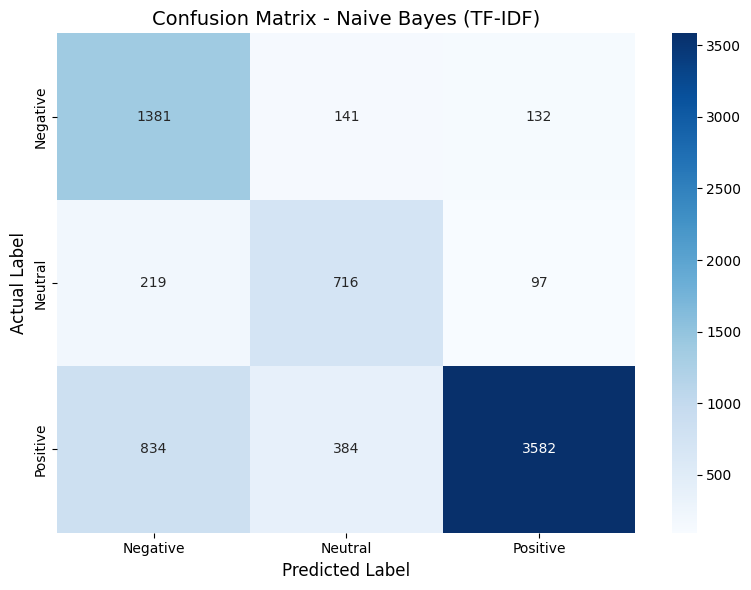

In [ ]:
# Convert token list to string
X = cleaned_dataframe['Content'].apply(lambda x: ' '.join(eval(x)) if isinstance(x, str) else ' '.join(x))
y = cleaned_dataframe['Sentiment']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Vectorize
vectorizer = TfidfVectorizer(
    max_features=10000,     
    min_df=5,               
    max_df=0.95,            
    ngram_range=(1, 2) ,
    stop_words = 'english',
    norm = 'l2',
    lowercase = True     
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

smote = SMOTE(
    sampling_strategy = {'Neutral': 23998,
                         'Negative': 23998},
    random_state = 42
)

X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train)

# Train
nb_model = MultinomialNB(alpha = 1.0,
                         force_alpha = True,
                         fit_prior = True,
                         class_prior = None
                         )
nb_model.fit(X_train_res, y_train_res)

# Evaluate
y_pred = nb_model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)

plt.title('Confusion Matrix - Naive Bayes (TF-IDF)', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 Logistic Regression

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Model training completed successfully!

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.70      0.84      0.77      1654
 Neutral (1)       0.59      0.89      0.71      1032
Positive (2)       0.96      0.79      0.87      4800

    accuracy                           0.82      7486
   macro avg       0.75      0.84      0.78      7486
weighted avg       0.85      0.82      0.82      7486



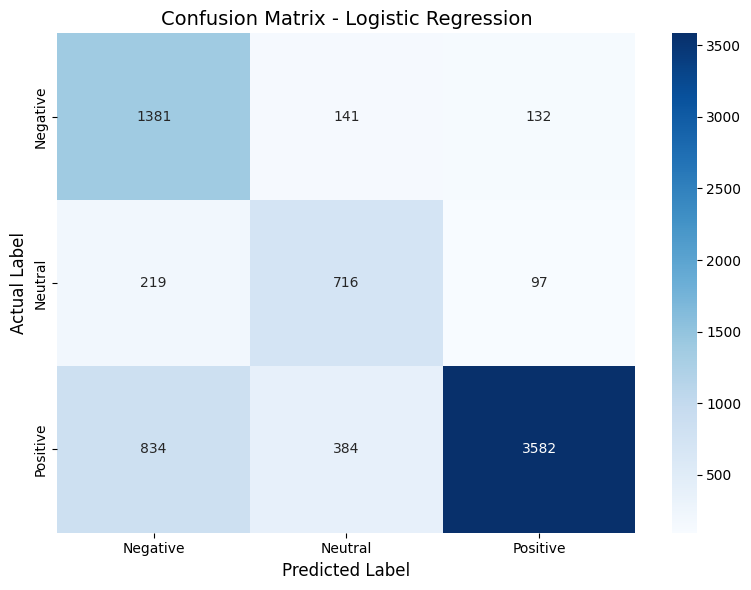

In [ ]:
# --- Step 4: Train Model ---
model = LogisticRegression(
    penalty='l2',
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
)

model.fit(X_train_res, y_train_res)  # Train on resampled data
print("Model training completed successfully!")

# --- Step 5: Evaluate Model ---
y_pred = model.predict(X_test_vec)

# Classification report
target_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

cm = confusion_matrix(y_test, y_pred)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### 3.3 Advanced NLP: ROBERTA

In [ ]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================

# Ensure your text column contains clean strings
df['Cleaned_Text'] = df['Translated_Review'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

# Define your 3-class mappings
label2id = {"Positive": 0, "Neutral": 1, "Negative": 2}
id2label = {0: "Positive", 1: "Neutral", 2: "Negative"}

# Map text sentiments to numerical labels
df['label'] = df['Sentiment'].map(label2id)

# Split into 80% Train and 20% Validation/Test sets (stratified)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Convert Pandas DataFrames into Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df[['Cleaned_Text', 'label']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['Cleaned_Text', 'label']].reset_index(drop=True))

# ==========================================
# 2. TOKENIZATION (SWITCHED TO ROBERTA)
# ==========================================

# Load the RoBERTa-base tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_function(examples):
    # RoBERTa uses a different byte-level BPE tokenizer, but truncation logic is identical
    return tokenizer(examples["Cleaned_Text"], truncation=True, max_length=128)

# Apply tokenization across datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Data collator dynamically pads inputs to the longest sequence in each batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ==========================================
# 3. MODEL & METRICS SETUP (SWITCHED TO ROBERTA)
# ==========================================

# Load RoBERTa for sequence classification with 3 labels
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", 
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Load accuracy metric for evaluation tracking
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

# ==========================================
# 4. TRAINING ARGUMENTS & TRAINING
# ==========================================

training_args = TrainingArguments(
    output_dir="./roberta_app_classifier",
    eval_strategy="epoch",            
    save_strategy="epoch",            
    learning_rate=2e-5,               
    per_device_train_batch_size=16,   # NOTE: If you get a GPU Out-of-Memory (OOM) error, change this to 8
    per_device_eval_batch_size=32,
    num_train_epochs=3,               
    weight_decay=0.01,                
    load_best_model_at_end=True,      
    metric_for_best_model="accuracy",
    logging_steps=100,
    fp16=True                         # Highly recommended for RoBERTa to speed up training
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Start training loop
trainer.train()

# Save final calibrated model and tokenizer
trainer.save_model("./best_roberta_classifier")
tokenizer.save_pretrained("./best_roberta_classifier")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_roberta_classifier\\tokenizer_config.json',
 './best_roberta_classifier\\tokenizer.json')


=== ROBERTA CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Positive       0.97      0.97      0.97      4800
     Neutral       0.95      0.90      0.93      1032
    Negative       0.91      0.92      0.91      1654

    accuracy                           0.95      7486
   macro avg       0.94      0.93      0.94      7486
weighted avg       0.95      0.95      0.95      7486



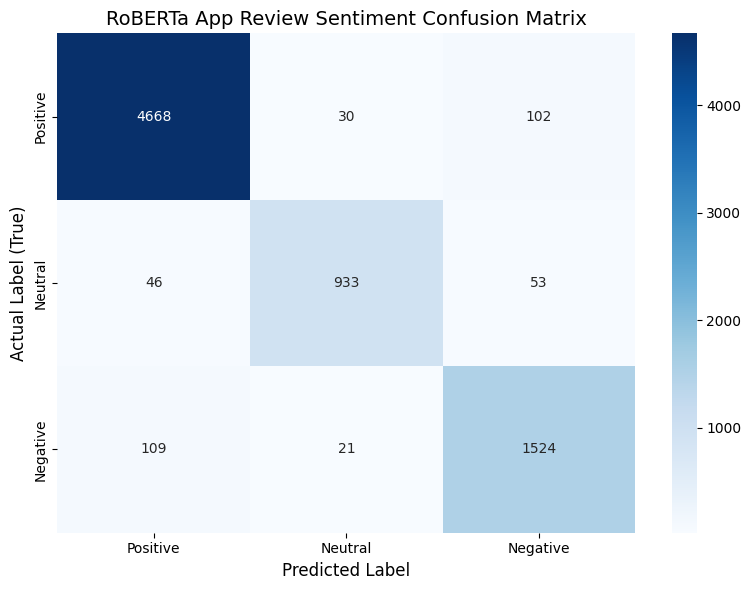

In [ ]:
# ==========================================
# 1. GENERATE PREDICTIONS
# ==========================================

# Extract predictions from your trainer using the validation dataset
raw_predictions = trainer.predict(tokenized_val)

# Convert raw model outputs (logits) into predicted class integers (0, 1, or 2)
predicted_labels = np.argmax(raw_predictions.predictions, axis=-1)

# Get the ground truth labels from the dataset
true_labels = raw_predictions.label_ids

# Define class names exactly aligned with your 0, 1, 2 mapping
class_names = ["Positive", "Neutral", "Negative"]

# ==========================================
# 2. PRINT CLASSIFICATION REPORT
# ==========================================
print("\n=== ROBERTA CLASSIFICATION REPORT ===")
print(
    classification_report(
        true_labels, predicted_labels, target_names=class_names
    )
)

# ==========================================
# 3. PLOT CONFUSION MATRIX
# ==========================================

# Calculate the confusion matrix numbers
cm = confusion_matrix(true_labels, predicted_labels)

# Initialize the plot size
plt.figure(figsize=(8, 6))

# Create a heatmap visualization
sns.heatmap(
    cm,
    annot=True,  # Show numbers inside the squares
    fmt="d",  # Display numbers as plain integers
    cmap="Blues",  # Set color scheme to blue tones
    xticklabels=class_names,
    yticklabels=class_names,
)

# Style your plot for readability
plt.title("RoBERTa App Review Sentiment Confusion Matrix", fontsize=14)
plt.ylabel("Actual Label (True)", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()

# Display the visualization block
plt.show()


## 4.0 Model Performance Comparison


| Metric | Multinomial Naive Bayes | Logistic Regression | roberta-base |
| :--- | :---: | :---: | :---: |
| **Accuracy** | 76% | 82% | 95% |
| **F1-score** | 0.71 | 0.78 | 0.94 |
| **Negative Precision** | 0.57 | 0.70 | 0.91 |
| **Negative Recall** | 0.83 | 0.84 | 0.92 |
| **Neutral Precision** | 0.58 | 0.59 | 0.95 |
| **Neutral Recall** | 0.69 | 0.89 | 0.90 |
| **Positive Precision** | 0.94 | 0.96 | 0.97 |
| **Positive Recall** | 0.75 | 0.79 | 0.97 |